In [ ]:
!pip install xgboost openpyxl transformers datasets accelerate wordcloud

# **Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, auc,
    matthews_corrcoef, log_loss
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from wordcloud import WordCloud

sns.set_style("whitegrid")

# **Upload and load the dataset**

In [ ]:
uploaded = files.upload()

Saving environment_disaster.xlsx to environment_disaster.xlsx


In [ ]:
df = pd.read_excel("environment_disaster.xlsx")

print("Dataset shape:", df.shape)
print(df.head())
print(df.columns)

Dataset shape: (1354, 5)
                                               Title  \
0  In the wake of fire, how South Korea is climat...   
1  In the wake of fire, how South Korea is climat...   
2  President Trump and Administrator Zeldin Deliv...   
3  Government announces emergency response for ea...   
4  Government announces emergency response for ea...   

                                                Text        Date  \
0  UNEP described restoration work after devastat...  2026-03-18   
1  UNEP described restoration work after devastat...  2026-03-18   
2  EPA announced elimination of the 2009 greenhou...  2026-02-12   
3  Rescue and rehabilitation efforts are ongoing ...  2026-02-09   
4  Recent scientific studies show increasing freq...  2026-02-06   

            Source            Author  
0  Weather Channel      Todd Bownwn   
1             UNEP      Todd Bownwn   
2  Weather Channel  EPA Press Office  
3  Weather Channel        Sophia Lee  
4  Weather Channel        Sophia L

In [ ]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns.tolist())

['title', 'text', 'date', 'source', 'author']


In [ ]:
required_cols = ['title', 'text', 'date', 'source', 'author']
for col in required_cols:
    if col not in df.columns:
        df[col] = ""

# **Check missing values and duplicates**

Handle missing Values

In [ ]:
df['title'] = df['title'].fillna('').astype(str)
df['text'] = df['text'].fillna('').astype(str)
df['source'] = df['source'].fillna('').astype(str)
df['author'] = df['author'].fillna('').astype(str)
df['date'] = df['date'].fillna('').astype(str)

In [ ]:
before_rows = len(df)

for col in ['title', 'text', 'source', 'author']:
    df[col] = df[col].astype(str).str.strip()

df = df.drop_duplicates(subset=['title', 'text', 'source', 'author'])

after_rows = len(df)

print("Rows before duplicate removal:", before_rows)
print("Rows after duplicate removal :", after_rows)
print("Duplicates removed           :", before_rows - after_rows)

Rows before duplicate removal: 1354
Rows after duplicate removal : 1204
Duplicates removed           : 150


In [ ]:
df['combined_text'] = df['title'] + " " + df['text']

# Clean the **text**

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\\S+|www\\S+|https\\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\\s]', ' ', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    return text

df['clean_text'] = df['combined_text'].apply(clean_text)
df['clean_source'] = df['source'].str.lower().str.strip()
df['clean_author'] = df['author'].str.lower().str.strip()

print(df[['title', 'source', 'clean_text']].head())

                                               title           source  \
0  In the wake of fire, how South Korea is climat...  Weather Channel   
1  In the wake of fire, how South Korea is climat...             UNEP   
2  President Trump and Administrator Zeldin Deliv...  Weather Channel   
3  Government announces emergency response for ea...  Weather Channel   
4  Government announces emergency response for ea...  Weather Channel   

                                          clean_text  
0  in the wake of fire  how south korea is climat...  
1  in the wake of fire  how south korea is climat...  
2  president trump and administrator zeldin deliv...  
3  government announces emergency response for ea...  
4  government announces emergency response for ea...  


Define verified and unverified source lists and keyword lists

In [ ]:
verified_sources = [
    'reuters', 'bbc', 'national geographic', 'nasa', 'noaa', 'unep','RTÉ',
    'ipcc', 'who', 'un', 'world bank','eu','gove','epa','Al Jazeera Climate','Weather Channel','BBC Radio Ulster','RTA Radio','RTÉ Radio'
]

unverified_sources = [
    'facebook', 'whatsapp', 'telegram', 'unknown blog', 'blogspot','Twitter',
    'wordpress', 'anonymous', 'social media'
]

real_keywords = [
    'official report', 'government report', 'scientific study',
    'climate report', 'meteorological department', 'satellite data',
    'confirmed', 'verified', 'researchers', 'evidence',
    'environment agency', 'disaster management authority',
    'warning issued', 'evacuation order', 'according to experts','Infrastructure Desk','Public Services','Science Desk'
]

fake_keywords = [
    'hoax', 'conspiracy', 'rumor', 'shocking truth', 'unbelievable',
    'secret agenda', 'fake alert', 'viral claim', 'click here',
    'unverified', 'anonymous source', 'without proof',
    'miracle cure', 'hidden truth', 'exposed', 'leaked'
]

# Create labeling generation logic

In [ ]:
def count_keyword_matches(text, keyword_list):
    count = 0
    matched = []
    for kw in keyword_list:
        if kw.lower() in text:
            count += 1
            matched.append(kw)
    return count, matched

def assign_label(row):
    source = row['clean_source']
    text = row['clean_text']

    real_score = 0
    fake_score = 0
    reasons = []

    # Source-based scoring
    for src in verified_sources:
        if src in source:
            real_score += 3
            reasons.append(f"verified_source:{src}")

    for src in unverified_sources:
        if src in source:
            fake_score += 3
            reasons.append(f"unverified_source:{src}")

    # Keyword-based scoring
    real_kw_count, real_matched = count_keyword_matches(text, real_keywords)
    fake_kw_count, fake_matched = count_keyword_matches(text, fake_keywords)

    real_score += real_kw_count
    fake_score += fake_kw_count

    if real_matched:
        reasons.append("real_keywords:" + ",".join(real_matched))
    if fake_matched:
        reasons.append("fake_keywords:" + ",".join(fake_matched))

    # Final label
    if real_score > fake_score:
        label = "Real"
    elif fake_score > real_score:
        label = "Fake"
    else:
        label = "Unknown"

    return pd.Series([label, "; ".join(reasons), real_score, fake_score])

df[['label', 'label_reason', 'real_score', 'fake_score']] = df.apply(assign_label, axis=1)

# Check the generated labels

In [ ]:
print(df['label'].value_counts())
print(df[['source', 'label', 'label_reason', 'real_score', 'fake_score']].head(10))

label
Real       806
Unknown    306
Fake        92
Name: count, dtype: int64
            source    label                              label_reason  \
0  Weather Channel  Unknown                                             
1             UNEP     Real  verified_source:unep; verified_source:un   
2  Weather Channel  Unknown                                             
3  Weather Channel  Unknown                                             
4  Weather Channel  Unknown                                             
5  Weather Channel     Real   real_keywords:meteorological department   
6  Weather Channel  Unknown                                             
7  Weather Channel  Unknown                                             
8  Weather Channel  Unknown                                             
9  Weather Channel  Unknown                                             

   real_score  fake_score  
0           0           0  
1           6           0  
2           0           0  
3      

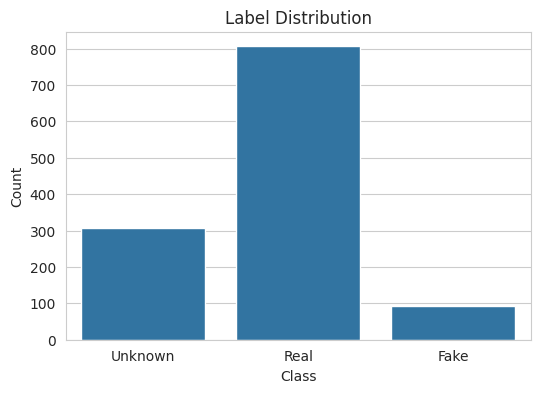

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

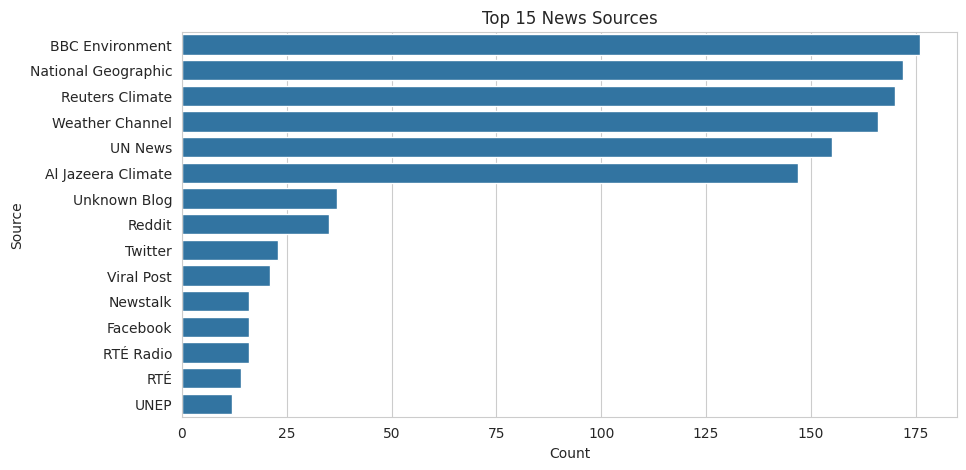

In [ ]:
top_sources = df['source'].value_counts().head(15)

plt.figure(figsize=(10,5))
sns.barplot(x=top_sources.values, y=top_sources.index)
plt.title("Top 15 News Sources")
plt.xlabel("Count")
plt.ylabel("Source")
plt.show()

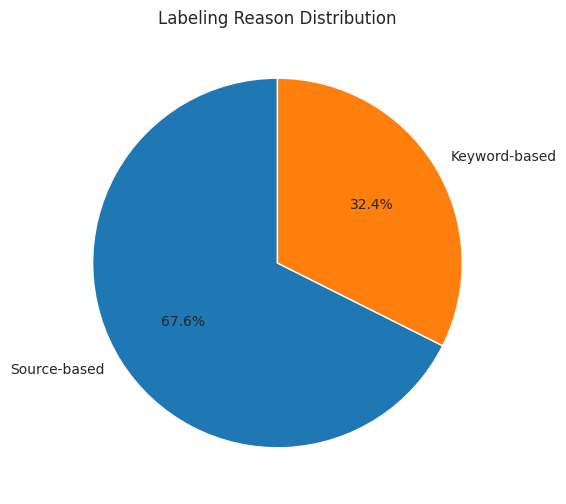

In [ ]:
source_based = df['label_reason'].str.contains('source', case=False, na=False).sum()
keyword_based = df['label_reason'].str.contains('keywords', case=False, na=False).sum()

reason_counts = pd.Series({
    'Source-based': source_based,
    'Keyword-based': keyword_based
})

plt.figure(figsize=(6,6))
plt.pie(
    reason_counts,
    labels=reason_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Labeling Reason Distribution")
plt.show()

# Save the cleaned and labeled **dataset**

In [ ]:
df.to_csv("environment_disaster_labeled_cleaned.csv", index=False)
df.to_excel("environment_disaster_labeled_cleaned.xlsx", index=False)

print("Saved cleaned labeled dataset successfully.")

Saved cleaned labeled dataset successfully.


Check specific titles in your dataset and print all corresponding rows

In [ ]:
titles_to_check = [
    "EPA Delivers 500 Environmental Wins During President Trump's First Year Back in the White House",
    "President Trump and Administrator Zeldin Deliver Single Largest Deregulatory Action in U.S. History",
    "EPA Releases First Quarterly Public Update on Progress Toward Implementing Permanent 100% Solution",
    "Trump Administration Announces Another Historic Milestone Toward Implementing 100% Solution to the Tijuana River Sewage Crisis",
    "EPA and US IBWC Announce Major Milestone in Delivering 100% Solution to Tijuana River Sewage Crisis",
    "United States and Mexico Reach Agreement to Permanently and Urgently End Decades-Long Tijuana River Sewage Crisis",
    "EPA Issues Final Rule to Extend Unrealistic Biden-era Compliance Deadlines for Oil and Gas",
    "Ambition to tackle climate change weakened by Trump",
    "2025 on track to tie second hottest year on record - monitor",
    "Virtually impossible to achieve 1.5C climate target, says UN",
    "Climate projects too small to secure funding, says report",
    "Over 50 hot days can be avoided under Paris Agreement",
    "Raw sewage discharges halved since last year, says EPA",
    "EPA identifies 115 risks to Ireland from climate change",
    "In the wake of fire, how South Korea is climate-proofing its forests and communities",
    "Without big changes, this is what the environment will look like in 2050",
    "Climate change drives rising temperatures and severe drought in Uzbekistan, shows new UNEP Atlas",
    "World's first impact bond on weather and climate data opens for contributions",
    "AI has an environmental problem. Here's what the world can do about that",
    "The world is likely to exceed a key global warming target soon. Now what?"
]

# Fix: Create 'clean_title' column before using it
df['clean_title'] = df['title'].apply(clean_text)

for title in titles_to_check:
    clean_title = clean_text(title)
    matched_rows = df[df['clean_title'] == clean_title][['title', 'text', 'date', 'source', 'author']]

    print("\n" + "=" * 140)
    print("TITLE CHECKED:", title)
    print("=" * 140)

    if matched_rows.empty:
        print("NOT FOUND in dataset.")
    else:
        print(f"FOUND {len(matched_rows)} matching row(s):\n")
        print(matched_rows.to_string(index=False))


TITLE CHECKED: EPA Delivers 500 Environmental Wins During President Trump's First Year Back in the White House
FOUND 1 matching row(s):

                                                                                          title                                                                                                                                                    text       date          source           author
EPA Delivers 500 Environmental Wins During President Trump's First Year Back in the White House EPA said it had delivered 500 environmental wins, including actions on the Tijuana River sewage crisis, lead in drinking water, and wastewater permits. 2026-01-20 Weather Channel EPA Press Office

TITLE CHECKED: President Trump and Administrator Zeldin Deliver Single Largest Deregulatory Action in U.S. History
FOUND 1 matching row(s):

                                                                                              title                                     

Credibility Feature Analysis


Average credibility feature values for Real vs Fake:

       has_numbers  official_mention  science_reference  sensational_score  \
label                                                                        
Fake           0.0          0.347826           0.456522           0.369565   
Real           0.0          0.631514           0.348635           0.060794   

       word_count  credibility_score  
label                                 
Fake    23.173913           1.239130  
Real    25.769231           1.899504  


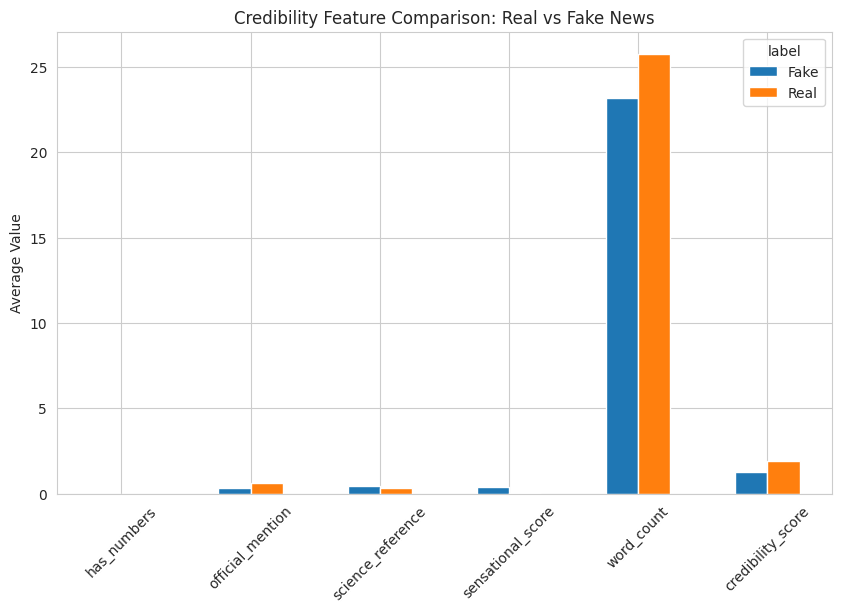

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 1. CREATE CREDIBILITY FEATURES BEFORE MODEL BUILDING
# =========================================================

official_entities = [
    'government', 'ministry', 'department', 'meteorological',
    'environment agency', 'epa', 'unep', 'ipcc', 'who', 'nasa',
    'official', 'authority'
]

science_words = [
    'study', 'research', 'report', 'analysis',
    'data', 'satellite', 'scientists'
]

sensational_words = [
    'shocking', 'unbelievable', 'secret',
    'conspiracy', 'viral', 'exposed'
]

# Presence of numbers
df['has_numbers'] = df['clean_text'].str.contains(r'\d', regex=True).astype(int)

# Official entity mention
df['official_mention'] = df['clean_text'].apply(
    lambda x: int(any(ent in x for ent in official_entities))
)

# Science reference
df['science_reference'] = df['clean_text'].apply(
    lambda x: int(any(word in x for word in science_words))
)

# Sensational score
df['sensational_score'] = df['clean_text'].apply(
    lambda x: sum(word in x for word in sensational_words)
)

# Word count
df['word_count'] = df['clean_text'].apply(lambda x: len(str(x).split()))

# Credibility score
df['credibility_score'] = (
    df['has_numbers'] * 2
    + df['official_mention'] * 2
    + df['science_reference'] * 2
    + (df['word_count'] > 200).astype(int)
    - df['sensational_score']
)

# Keep only Real and Fake
credibility_analysis_df = df[df['label'].isin(['Real', 'Fake'])].copy()

# Average feature values by class
feature_summary = credibility_analysis_df.groupby('label')[
    ['has_numbers', 'official_mention', 'science_reference',
     'sensational_score', 'word_count', 'credibility_score']
].mean()

print("\nAverage credibility feature values for Real vs Fake:\n")
print(feature_summary)

# Plot credibility features
feature_summary.T.plot(kind='bar', figsize=(10, 6))
plt.title("Credibility Feature Comparison: Real vs Fake News")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.show()

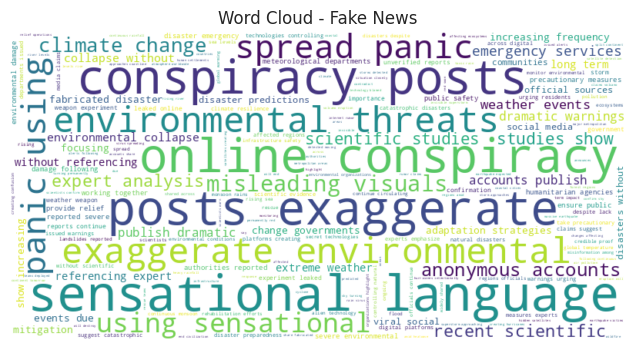

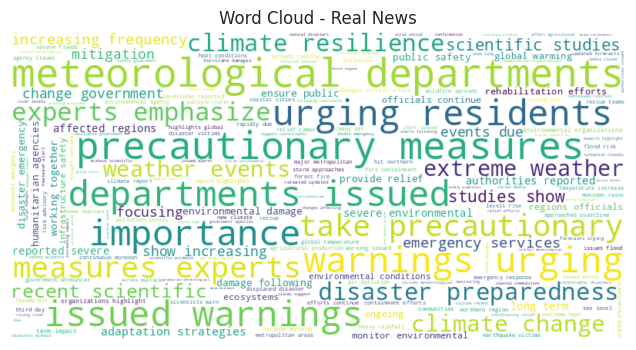

In [ ]:
df_model = df[df['label'] != 'Unknown'].copy()
df_model['target'] = df_model['label'].map({'Fake': 0, 'Real': 1})

!pip install wordcloud
from wordcloud import WordCloud

fake_text = " ".join(df_model[df_model['label'] == 'Fake']['clean_text'].astype(str))
real_text = " ".join(df_model[df_model['label'] == 'Real']['clean_text'].astype(str))

fake_wc = WordCloud(width=800, height=400, background_color='white').generate(fake_text)
real_wc = WordCloud(width=800, height=400, background_color='white').generate(real_text)

plt.figure(figsize=(10,4))
plt.imshow(fake_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Fake News")
plt.show()

plt.figure(figsize=(10,4))
plt.imshow(real_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Real News")
plt.show()

# **Prepare dataset for supervised learning**

In [ ]:
df_model = df[df['label'] != 'Unknown'].copy()

df_model['target'] = df_model['label'].map({'Fake': 0, 'Real': 1})

print("Final model dataset shape:", df_model.shape)
print(df_model['label'].value_counts())

Final model dataset shape: (898, 21)
label
Real    806
Fake     92
Name: count, dtype: int64


# **Train-test split**

In [ ]:
X = df_model['clean_text']
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 718
Test size: 180


In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Fake', 'Real'],
                yticklabels=['Fake', 'Real'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

def evaluate_model(name, y_true, y_pred, y_prob=None, train_time=None):
    result = {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'Train Time (s)': train_time
    }

    if y_prob is not None:
        result['ROC-AUC'] = roc_auc_score(y_true, y_prob)
        precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
        result['PR-AUC'] = auc(recall_vals, precision_vals)
        result['Log Loss'] = log_loss(y_true, y_prob)
    else:
        result['ROC-AUC'] = np.nan
        result['PR-AUC'] = np.nan
        result['Log Loss'] = np.nan

    return result

## Logistic Regression model

Logistic Regression
Accuracy: 0.8888888888888888
              precision    recall  f1-score   support

        Fake       0.40      0.22      0.29        18
        Real       0.92      0.96      0.94       162

    accuracy                           0.89       180
   macro avg       0.66      0.59      0.61       180
weighted avg       0.87      0.89      0.87       180



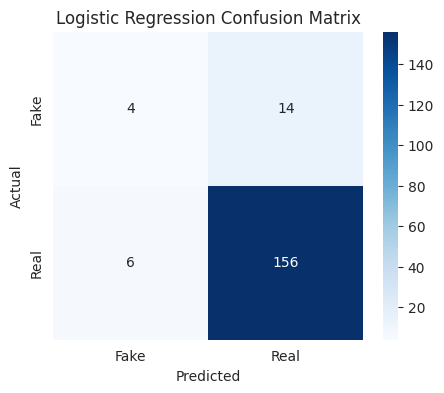

In [ ]:
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000))
])

start_time = time.time()
lr_pipeline.fit(X_train, y_train)
lr_train_time = time.time() - start_time

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=['Fake', 'Real']))

plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")

lr_result = evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_prob=y_prob_lr,
    train_time=lr_train_time
)

# **XGBoost model**

XGBoost
Accuracy: 0.8777777777777778
              precision    recall  f1-score   support

        Fake       0.39      0.39      0.39        18
        Real       0.93      0.93      0.93       162

    accuracy                           0.88       180
   macro avg       0.66      0.66      0.66       180
weighted avg       0.88      0.88      0.88       180



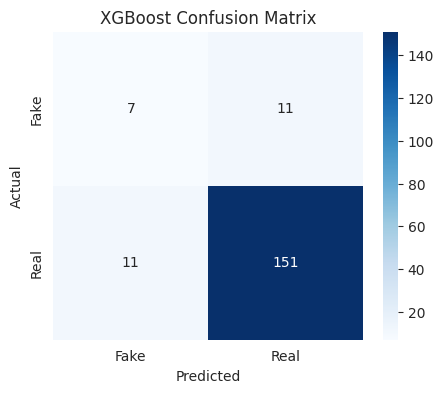

In [ ]:
xgb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
    ('clf', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    ))
])

start_time = time.time()
xgb_pipeline.fit(X_train, y_train)
xgb_train_time = time.time() - start_time

y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, target_names=['Fake', 'Real']))

plot_confusion_matrix(y_test, y_pred_xgb, "XGBoost Confusion Matrix")

xgb_result = evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob=y_prob_xgb,
    train_time=xgb_train_time
)

# **BiLSTM Model**

Prepare tokenizer and padded sequences

In [ ]:
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

Build the BiLSTM model

In [ ]:
dl_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

dl_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

dl_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

start_time = time.time()
history = dl_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)
dl_train_time = time.time() - start_time

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 608ms/step - accuracy: 0.8449 - loss: 0.5019 - val_accuracy: 0.9097 - val_loss: 0.2914
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 686ms/step - accuracy: 0.8937 - loss: 0.3404 - val_accuracy: 0.9097 - val_loss: 0.3079
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 239ms/step - accuracy: 0.8937 - loss: 0.2979 - val_accuracy: 0.9097 - val_loss: 0.2506
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 231ms/step - accuracy: 0.9059 - loss: 0.2599 - val_accuracy: 0.9167 - val_loss: 0.2430
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 317ms/step - accuracy: 0.9042 - loss: 0.2713 - val_accuracy: 0.9097 - val_loss: 0.2431
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 238ms/step - accuracy: 0.9094 - loss: 0.2505 - val_accuracy: 0.9097 - val_loss: 0.2423
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step - accuracy: 0.9199 - loss: 0.2711 - val_accuracy: 0.9097 - val_loss: 0.2527
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 235ms/step - accuracy: 0.9181 - loss: 0.2465 - val_accuracy:

Evaluate the Model

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 345ms/step
BiLSTM Results
Accuracy: 0.8777777777777778
              precision    recall  f1-score   support

        Fake       0.33      0.22      0.27        18
        Real       0.92      0.95      0.93       162

    accuracy                           0.88       180
   macro avg       0.62      0.59      0.60       180
weighted avg       0.86      0.88      0.87       180



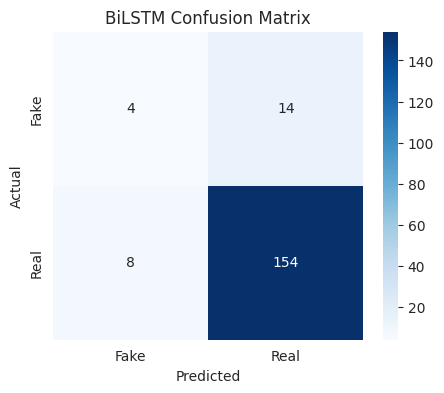

In [ ]:
dl_loss, dl_acc = dl_model.evaluate(X_test_pad, y_test, verbose=0)

y_prob_dl = dl_model.predict(X_test_pad).flatten()
y_pred_dl = (y_prob_dl > 0.5).astype(int)

print("BiLSTM Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dl))
print(classification_report(y_test, y_pred_dl, target_names=['Fake', 'Real']))

plot_confusion_matrix(y_test, y_pred_dl, "BiLSTM Confusion Matrix")

dl_result = evaluate_model(
    "BiLSTM",
    y_test,
    y_pred_dl,
    y_prob=y_prob_dl,
    train_time=dl_train_time
)

# **DistilRoBERTa transformer model**

Convert train and test data into dataset format

In [ ]:
train_texts = X_train.tolist()
test_texts = X_test.tolist()

train_labels = y_train.tolist()
test_labels = y_test.tolist()

train_df = pd.DataFrame({
    'text': train_texts,
    'label': train_labels
})

test_df = pd.DataFrame({
    'text': test_texts,
    'label': test_labels
})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
model_name = "distilroberta-base"

tokenizer_tr = AutoTokenizer.from_pretrained(model_name)
transformer_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Tokenize the text

In [ ]:
def tokenize_function(examples):
    return tokenizer_tr(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset.set_format("torch")
test_dataset.set_format("torch")

Map:   0%|          | 0/718 [00:00<?, ? examples/s]

Map:   0%|          | 0/180 [00:00<?, ? examples/s]

Define Metric Function

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)
    accuracy = accuracy_score(labels, predictions)

    probs = torch.nn.functional.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    roc_auc = roc_auc_score(labels, probs)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./distilroberta_results",
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=transformer_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

start_time = time.time()
trainer.train()
transformer_train_time = time.time() - start_time

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.368240,0.290255,0.900000,0.900000,1.000000,0.947368,0.796811


Evaluate transformer model

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


DistilRoBERTa Results
              precision    recall  f1-score   support

        Fake       0.00      0.00      0.00        18
        Real       0.90      1.00      0.95       162

    accuracy                           0.90       180
   macro avg       0.45      0.50      0.47       180
weighted avg       0.81      0.90      0.85       180



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


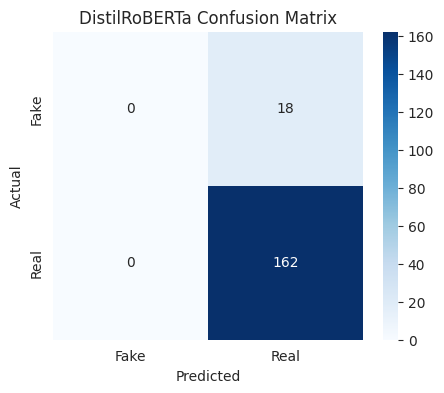

In [ ]:
transformer_eval = trainer.predict(test_dataset)

transformer_logits = transformer_eval.predictions
y_pred_transformer = np.argmax(transformer_logits, axis=1)
y_prob_transformer = torch.nn.functional.softmax(
    torch.tensor(transformer_logits), dim=1
)[:, 1].numpy()

print("DistilRoBERTa Results")
print(classification_report(test_labels, y_pred_transformer, target_names=["Fake", "Real"]))

plot_confusion_matrix(test_labels, y_pred_transformer, "DistilRoBERTa Confusion Matrix")

transformer_result = {
    'Model': 'DistilRoBERTa',
    'Accuracy': accuracy_score(test_labels, y_pred_transformer),
    'Precision': precision_score(test_labels, y_pred_transformer),
    'Recall': recall_score(test_labels, y_pred_transformer),
    'F1-score': f1_score(test_labels, y_pred_transformer),
    'MCC': matthews_corrcoef(test_labels, y_pred_transformer),
    'ROC-AUC': roc_auc_score(test_labels, y_prob_transformer),
    'PR-AUC': auc(
        precision_recall_curve(test_labels, y_prob_transformer)[1],
        precision_recall_curve(test_labels, y_prob_transformer)[0]
    ),
    'Log Loss': log_loss(test_labels, y_prob_transformer),
    'Train Time (s)': transformer_train_time
}

# **Create final comparison table**

In [ ]:
all_results = pd.DataFrame([
    lr_result,
    xgb_result,
    dl_result,
    transformer_result
])

all_results = all_results.sort_values(by='Accuracy', ascending=False)
print(all_results)

                 Model  Accuracy  Precision    Recall  F1-score       MCC  \
3        DistilRoBERTa  0.900000   0.900000  1.000000  0.947368  0.000000   
0  Logistic Regression  0.888889   0.917647  0.962963  0.939759  0.242536   
1              XGBoost  0.877778   0.932099  0.932099  0.932099  0.320988   
2               BiLSTM  0.877778   0.916667  0.950617  0.933333  0.207870   

   Train Time (s)   ROC-AUC    PR-AUC  Log Loss  
3      538.472104  0.796811  0.964144  0.290255  
0        0.350215  0.787723  0.959996  0.271953  
1        3.047962  0.751372  0.961486  0.415580  
2       86.574575  0.781550  0.959659  0.289389  


In [ ]:
all_results.to_csv("model_comparison_results.csv", index=False)

# **Plot model comparison charts**

Accuracy comparison

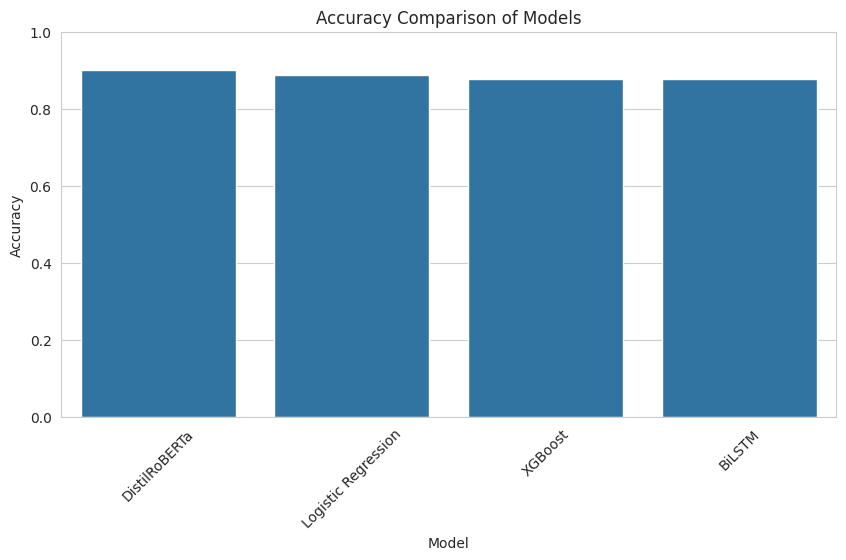

In [ ]:
all_results = pd.DataFrame([
    lr_result,
    xgb_result,
    dl_result,
    transformer_result
])

all_results = all_results.sort_values(by='Accuracy', ascending=False)
print(all_results)

Precision, Recall, F1-score comparison

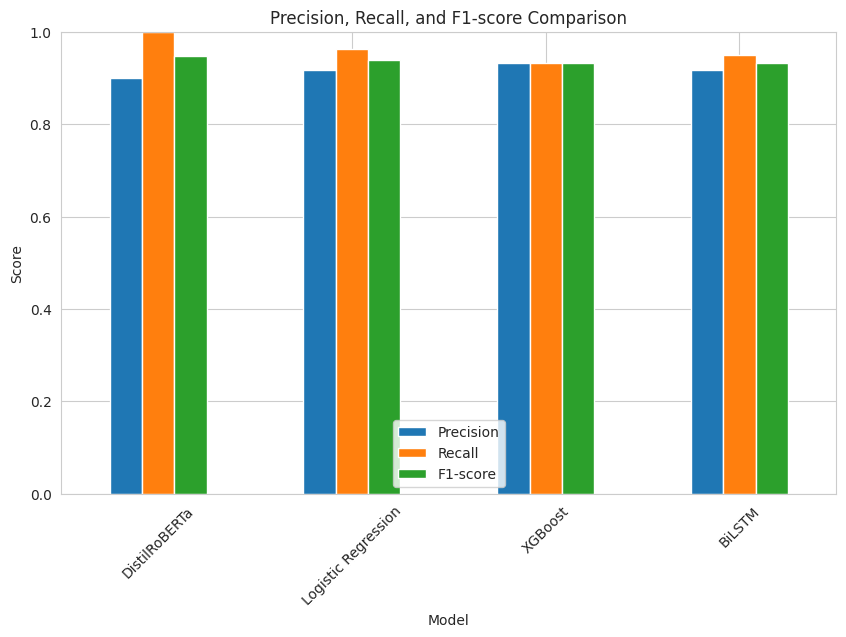

In [ ]:
metrics_plot = all_results.set_index('Model')[['Precision', 'Recall', 'F1-score']]
metrics_plot.plot(kind='bar', figsize=(10,6))
plt.title("Precision, Recall, and F1-score Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

ROC-AUC, PR-AUC, MCC comparison

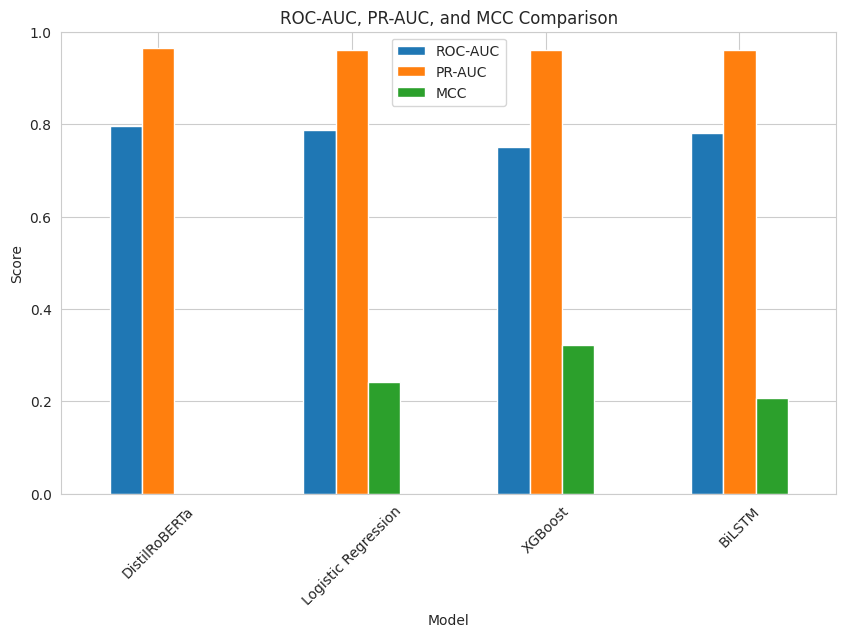

In [ ]:
metrics_plot2 = all_results.set_index('Model')[['ROC-AUC', 'PR-AUC', 'MCC']]
metrics_plot2.plot(kind='bar', figsize=(10,6))
plt.title("ROC-AUC, PR-AUC, and MCC Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

Training time comparison

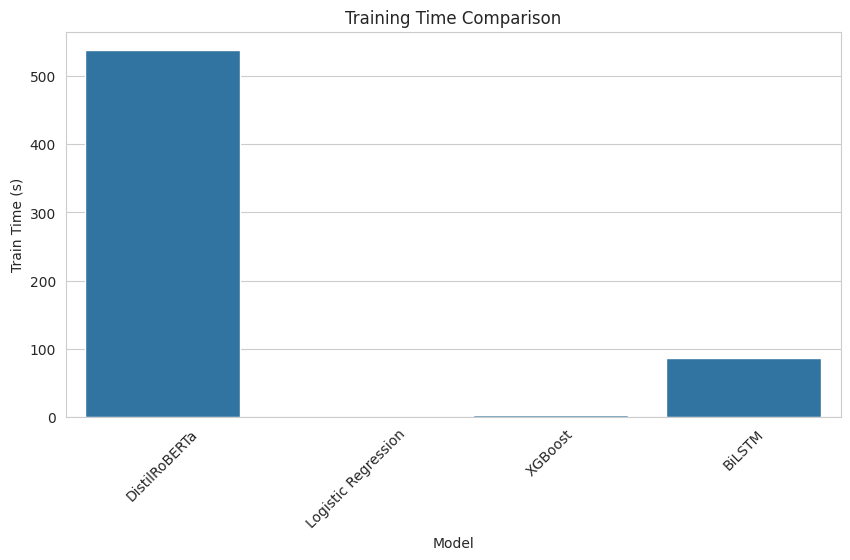

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='Train Time (s)', data=all_results)
plt.title("Training Time Comparison")
plt.xticks(rotation=45)
plt.show()

# **Plot ROC curve**

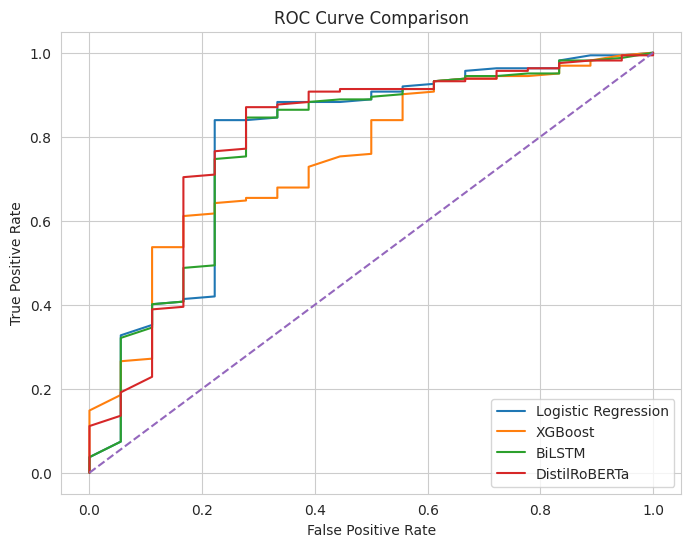

In [ ]:
plt.figure(figsize=(8,6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost')

fpr_dl, tpr_dl, _ = roc_curve(y_test, y_prob_dl)
plt.plot(fpr_dl, tpr_dl, label='BiLSTM')

fpr_tr, tpr_tr, _ = roc_curve(test_labels, y_prob_transformer)
plt.plot(fpr_tr, tpr_tr, label='DistilRoBERTa')

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# **Plot Precision-Recall curve**

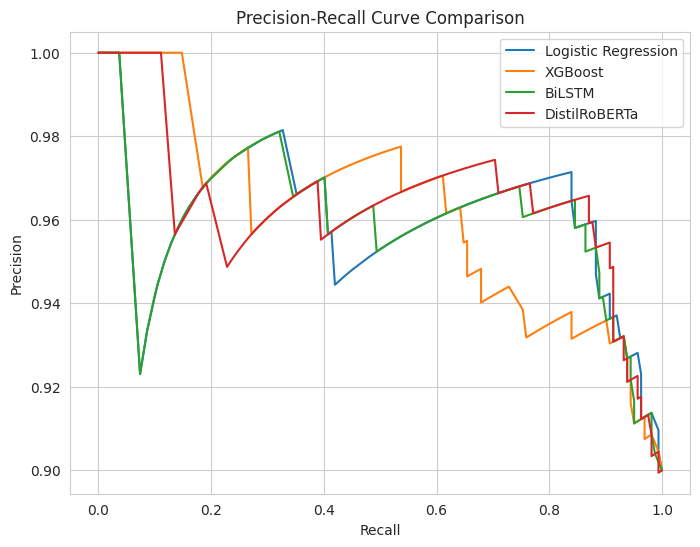

In [ ]:
plt.figure(figsize=(8,6))

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
plt.plot(recall_lr, precision_lr, label='Logistic Regression')

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
plt.plot(recall_xgb, precision_xgb, label='XGBoost')

precision_dl, recall_dl, _ = precision_recall_curve(y_test, y_prob_dl)
plt.plot(recall_dl, precision_dl, label='BiLSTM')

precision_tr, recall_tr, _ = precision_recall_curve(test_labels, y_prob_transformer)
plt.plot(recall_tr, precision_tr, label='DistilRoBERTa')

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

# **Plot BiLSTM learning curves**

Accuracy curve

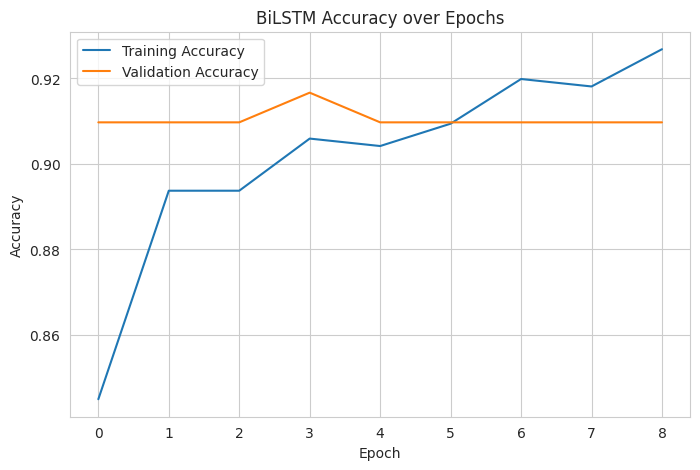

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("BiLSTM Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Loss curve

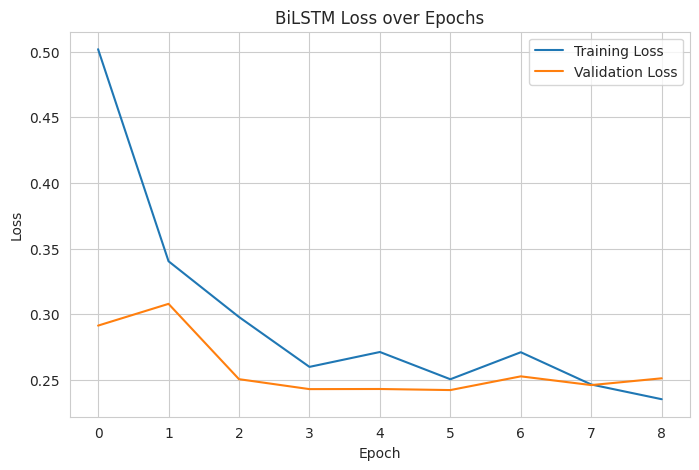

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("BiLSTM Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# **Find the best model**

In [ ]:
best_model = all_results.iloc[0]
print("Best Model:")
print(best_model)

Best Model:
Model             DistilRoBERTa
Accuracy                    0.9
Precision                   0.9
Recall                      1.0
F1-score               0.947368
MCC                         0.0
Train Time (s)       538.472104
ROC-AUC                0.796811
PR-AUC                 0.964144
Log Loss               0.290255
Name: 3, dtype: object


In [ ]:
# -------------------------------------------------
# 4. Choose one final best model
# Rule:
# Prefer highest F1-score, then highest Accuracy, then highest MCC
# -------------------------------------------------
final_best_model = all_results.sort_values(
    by=['F1-score', 'Accuracy', 'MCC'],
    ascending=False
).iloc[0]

print("\nFinal Best Model:")
print(final_best_model.round(4))


Final Best Model:
Model             DistilRoBERTa
Accuracy                    0.9
Precision                   0.9
Recall                      1.0
F1-score               0.947368
MCC                         0.0
Train Time (s)       538.472104
ROC-AUC                0.796811
PR-AUC                 0.964144
Log Loss               0.290255
Name: 3, dtype: object
